# SALT3 Single Spectrum Fitting
This notebook allows you to load a single supernova spectrum, fit it using the SALT3 model with `dynesty`, and visualize the results including convergence plots, corner plots, and the best-fit model compared to the data.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sncosmo
import dynesty
import corner
from dynesty import plotting as dyplot
from astropy.time import Time
from datetime import datetime

# Settings
SPECTRA_DIR = '/Users/pxm588@student.bham.ac.uk/PhD/bayesian_framework/data/all_spectra_dereddened'
PARAM_FILE = "../data/cfasnIa_param.dat"
SNID_RESULTS = "../outputs/method_comparison/cfa_SNID_results.csv"
MODEL_NAME = 'salt3'
NLIVE = 200

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('default')

## 1. Helper Functions

In [3]:
def parse_param_file(file_path):
    params = {}
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip(): continue
            parts = line.split()
            sn_name = parts[0].lower()
            params[sn_name] = {'z': float(parts[1]), 'mjd_max': float(parts[2])}
    return params

def load_flm_spectrum(file_path):
    data = np.genfromtxt(file_path, invalid_raise=False)
    wave, flux = data[:, 0], data[:, 1]
    err = data[:, 2] if data.shape[1] >= 3 else 0.1 * np.abs(flux)
    mask = np.isfinite(flux) & np.isfinite(err) & (err > 0)
    return wave[mask], flux[mask], err[mask]

def run_fit(wavelength, flux, flux_err, nlive, method='nuis', redshift=None):
    model = sncosmo.Model(source=MODEL_NAME)
    if redshift: model.set(z=redshift)
    
    if method == 'full':
        params = ['t0', 'x1', 'c', 'log10_x0']
        priors = {'t0': (-20, 30), 'x1': (-4, 4), 'c': (-0.4, 1.5), 'log10_x0': (-20, -2)}
    else:
        params = ['t0', 'x1', 'c']
        priors = {'t0': (-20, 30), 'x1': (-4, 4), 'c': (-0.4, 1.5)}

    def pt(u):
        t = np.zeros_like(u)
        for i, p in enumerate(params):
            low, high = priors[p]
            t[i] = u[i] * (high - low) + low
        return t

    def ll(t):
        p_dict = dict(zip(params, t))
        if 'log10_x0' in p_dict: p_dict['x0'] = 10**p_dict.pop('log10_x0')
        model.set(**p_dict)
        try:
            if method == 'nuis':
                model.set(x0=1.0)
                m_flux_unit = model.flux(0.0, wavelength)
                w = 1.0 / flux_err**2
                num, den = np.sum(flux * m_flux_unit * w), np.sum(m_flux_unit**2 * w)
                if den <= 0: return -1e10
                x0_best = num / den
                if x0_best <= 0: return -1e10
                chisq = np.sum(((flux - x0_best * m_flux_unit) / flux_err)**2)
            else:
                m_flux = model.flux(0.0, wavelength)
                chisq = np.sum(((flux - m_flux) / flux_err)**2)
            return -0.5 * chisq if not np.isnan(chisq) else -1e10
        except: return -1e10

    sampler = dynesty.NestedSampler(ll, pt, len(params), nlive=nlive, sample='rwalk')
    sampler.run_nested()
    return sampler.results, params

## 2. Load Data
Select a spectrum from the `data/all_spectra` directory.

Found metadata for sn2003cg-20030329.27-mmt.flm: z=0.0041, mjd_max=52729.4
True Phase: -2.12 d
SNID Phase: -0.90 d
Subtype: N


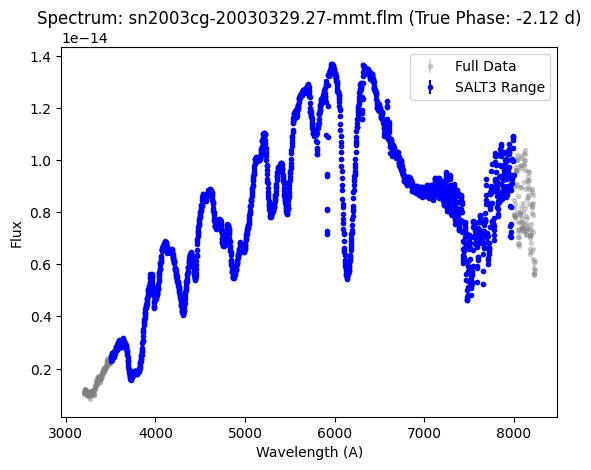

In [4]:
# Example file
FILENAME = 'sn2003cg-20030329.27-mmt.flm'
METHOD = 'nuis'  # 'nuis' (marginalized x0) or 'full' (sampled log10_x0)

sn_params = parse_param_file(PARAM_FILE)
sn_id = FILENAME.split('-')[0]
param_lookup = sn_id[2:] if sn_id.startswith('sn') else sn_id
p = sn_params.get(param_lookup.lower())

# Get True Phase from SNID results if available
true_phase = None
snid_phase = None
if os.path.exists(SNID_RESULTS):
    df_snid = pd.read_csv(SNID_RESULTS)
    row = df_snid[df_snid['Filename'] == FILENAME]
    if not row.empty:
        true_phase = row['Age_(days)'].values[0]
        snid_phase = row['bootstrap_age'].values[0]
        subtype = row['Subtype'].values[0]

if p:
    print(f"Found metadata for {FILENAME}: z={p['z']}, mjd_max={p['mjd_max']}")
    if true_phase is not None:
        print(f"True Phase: {true_phase:.2f} d")
        print(f"SNID Phase: {snid_phase:.2f} d")
        print(f"Subtype: {subtype}")
    wave, flux, err = load_flm_spectrum(os.path.join(SPECTRA_DIR, FILENAME))
    
    # Apply SALT3 wavelength range mask
    mask = (wave > 3500) & (wave < 8000)
    wave_f, flux_f, err_f = wave[mask], flux[mask], err[mask]
    
    plt.errorbar(wave, flux, yerr=err, fmt='.', color='gray', alpha=0.3, label='Full Data')
    plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='blue', label='SALT3 Range')
    title = f"Spectrum: {FILENAME}"
    if true_phase is not None: title += f" (True Phase: {true_phase:.2f} d)"
    plt.title(title)
    plt.xlabel("Wavelength (A)")
    plt.ylabel("Flux")
    plt.legend()
    plt.show()
else:
    print(f"Error: Metadata for {sn_id} not found in {PARAM_FILE}")

Found metadata for sn2003cg-20030329.27-mmt.flm: z=0.0041, mjd_max=52729.4
True Phase: -2.12 d
SNID Phase: -0.90 d
Subtype: N


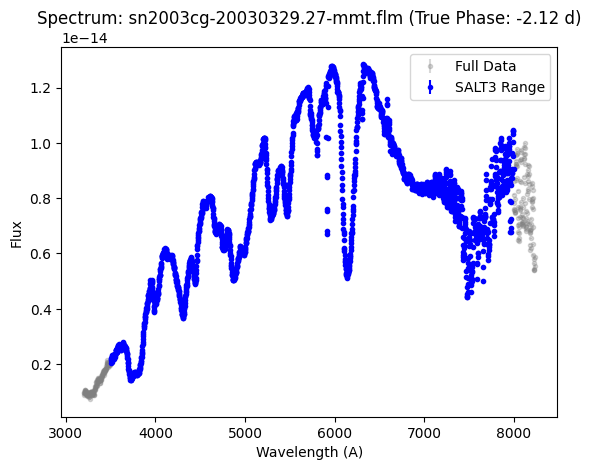

In [5]:
# Example file
FILENAME = 'sn2003cg-20030329.27-mmt.flm'
METHOD = 'nuis'  # 'nuis' (marginalized x0) or 'full' (sampled log10_x0)

sn_params = parse_param_file(PARAM_FILE)
sn_id = FILENAME.split('-')[0]
param_lookup = sn_id[2:] if sn_id.startswith('sn') else sn_id
p = sn_params.get(param_lookup.lower())

# Get True Phase from SNID results if available
true_phase = None
snid_phase = None
if os.path.exists(SNID_RESULTS):
    df_snid = pd.read_csv(SNID_RESULTS)
    row = df_snid[df_snid['Filename'] == FILENAME]
    if not row.empty:
        true_phase = row['Age_(days)'].values[0]
        snid_phase = row['bootstrap_age'].values[0]
        subtype = row['Subtype'].values[0]

if p:
    print(f"Found metadata for {FILENAME}: z={p['z']}, mjd_max={p['mjd_max']}")
    if true_phase is not None:
        print(f"True Phase: {true_phase:.2f} d")
        print(f"SNID Phase: {snid_phase:.2f} d")
        print(f"Subtype: {subtype}")
    wave, flux, err = load_flm_spectrum(os.path.join('/Users/pxm588@student.bham.ac.uk/PhD/bayesian_framework/data/all_spectra', FILENAME))

    # Apply SALT3 wavelength range mask
    mask = (wave > 3500) & (wave < 8000)
    wave_f, flux_f, err_f = wave[mask], flux[mask], err[mask]

    plt.errorbar(wave, flux, yerr=err, fmt='.', color='gray', alpha=0.3, label='Full Data')
    plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='blue', label='SALT3 Range')
    title = f"Spectrum: {FILENAME}"
    if true_phase is not None: title += f" (True Phase: {true_phase:.2f} d)"
    plt.title(title)
    plt.xlabel("Wavelength (A)")
    plt.ylabel("Flux")
    plt.legend()
    plt.show()
else:
    print(f"Error: Metadata for {sn_id} not found in {PARAM_FILE}")

Text(0, 0.5, 'F|lux')

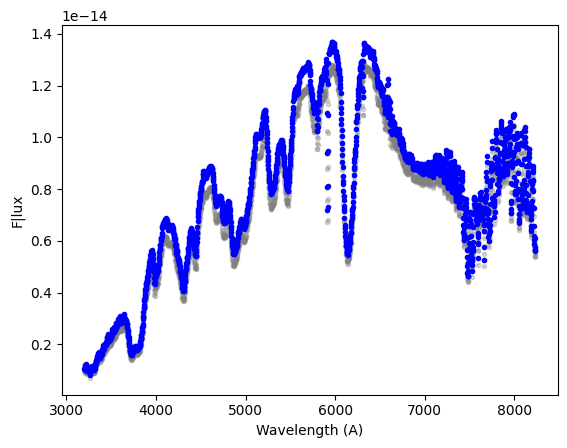

In [6]:
wave_1, flux_1, err_1 = load_flm_spectrum(os.path.join('/Users/pxm588@student.bham.ac.uk/PhD/bayesian_framework/data/all_spectra', FILENAME))

wave_2, flux_2, err_2 = load_flm_spectrum(os.path.join('/Users/pxm588@student.bham.ac.uk/PhD/bayesian_framework/data/all_spectra_dereddened', FILENAME))

plt.errorbar(wave_1, flux_1, yerr=err_1, fmt='.', color='gray', alpha=0.3, label='no dereddening')
plt.errorbar(wave_2, flux_2, yerr=err_2, fmt='.', color='blue', label='dereddened')

plt.xlabel("Wavelength (A)")
plt.ylabel("F|lux")